### Connect to Binance API

In [4]:
import websocket
import json
import time

socket = "wss://stream.binance.com:9443/ws/btcusdt@trade"

last_print = 0

def on_message(ws, message):
    global last_print
    data = json.loads(message)
    
    now = time.time()
    if now - last_print >= 5:
        print("BTC price:", data["p"])
        last_print = now

ws = websocket.WebSocketApp(socket, on_message=on_message)
ws.run_forever()

BTC price: 69678.70000000
BTC price: 69678.70000000
BTC price: 69678.71000000
BTC price: 69678.71000000
BTC price: 69678.70000000
BTC price: 69711.07000000
BTC price: 69755.95000000
BTC price: 69727.03000000
BTC price: 69722.49000000
BTC price: 69729.05000000
BTC price: 69729.05000000
BTC price: 69715.90000000
BTC price: 69715.91000000
BTC price: 69715.90000000
BTC price: 69715.90000000
BTC price: 69715.91000000
BTC price: 69720.29000000
BTC price: 69699.99000000
BTC price: 69691.33000000
BTC price: 69691.08000000
BTC price: 69685.69000000
BTC price: 69676.10000000
BTC price: 69648.53000000
BTC price: 69638.77000000
BTC price: 69638.77000000
BTC price: 69638.76000000
BTC price: 69638.76000000
BTC price: 69646.05000000
BTC price: 69657.18000000
BTC price: 69657.90000000
BTC price: 69669.31000000
BTC price: 69681.97000000
BTC price: 69690.70000000


True

In [39]:
import requests
import pandas as pd

url = "https://api.binance.com/api/v3/klines"

params = {
    "symbol": "BTCUSDT",
    "interval": "5m",
    "limit": 100000
}

data = requests.get(url, params=params).json()

df = pd.DataFrame(data, columns=[
    "time","open","high","low","close","volume",
    "close_time","qav","num_trades","taker_base",
    "taker_quote","ignore"
])

df["close"] = df["close"].astype(float)
df["time"] = pd.to_datetime(df["time"], unit="ms")

df = df[["time","close"]]
print(df.head())

                 time     close
0 2026-03-07 11:30:00  68107.51
1 2026-03-07 11:35:00  68113.69
2 2026-03-07 11:40:00  68132.09
3 2026-03-07 11:45:00  68061.56
4 2026-03-07 11:50:00  68052.88


In [40]:
df["ma_fast"] = df["close"].rolling(10).mean()
df["ma_slow"] = df["close"].rolling(50).mean()

df["signal"] = 0
df.loc[df["ma_fast"] > df["ma_slow"], "signal"] = 1
df.loc[df["ma_fast"] < df["ma_slow"], "signal"] = -1

In [41]:
df["returns"] = df["close"].pct_change()

df["strategy_returns"] = df["signal"].shift(1) * df["returns"]

df["equity"] = (1 + df["strategy_returns"]).cumprod()

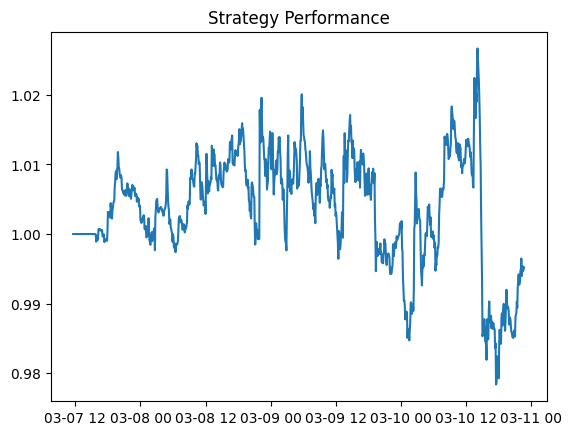

In [42]:
import matplotlib.pyplot as plt

plt.plot(df["time"], df["equity"])
plt.title("Strategy Performance")
plt.show()

In [26]:
total_return = df["equity"].iloc[-1] - 1
print("Total return:", total_return)

Total return: -0.008003857073976661


Start                         2026-01-09 23:30:00+00:00
End                           2026-03-10 23:30:00+00:00
Period                                 60 days 00:30:00
Start Value                                       100.0
End Value                                     85.322691
Total Return [%]                             -14.677309
Benchmark Return [%]                         -22.698231
Max Gross Exposure [%]                            100.0
Total Fees Paid                                2.563022
Max Drawdown [%]                              27.179048
Max Drawdown Duration                  54 days 14:00:00
Total Trades                                         15
Total Closed Trades                                  14
Total Open Trades                                     1
Open Trade PnL                                  0.07926
Win Rate [%]                                  35.714286
Best Trade [%]                                 4.851909
Worst Trade [%]                              -11

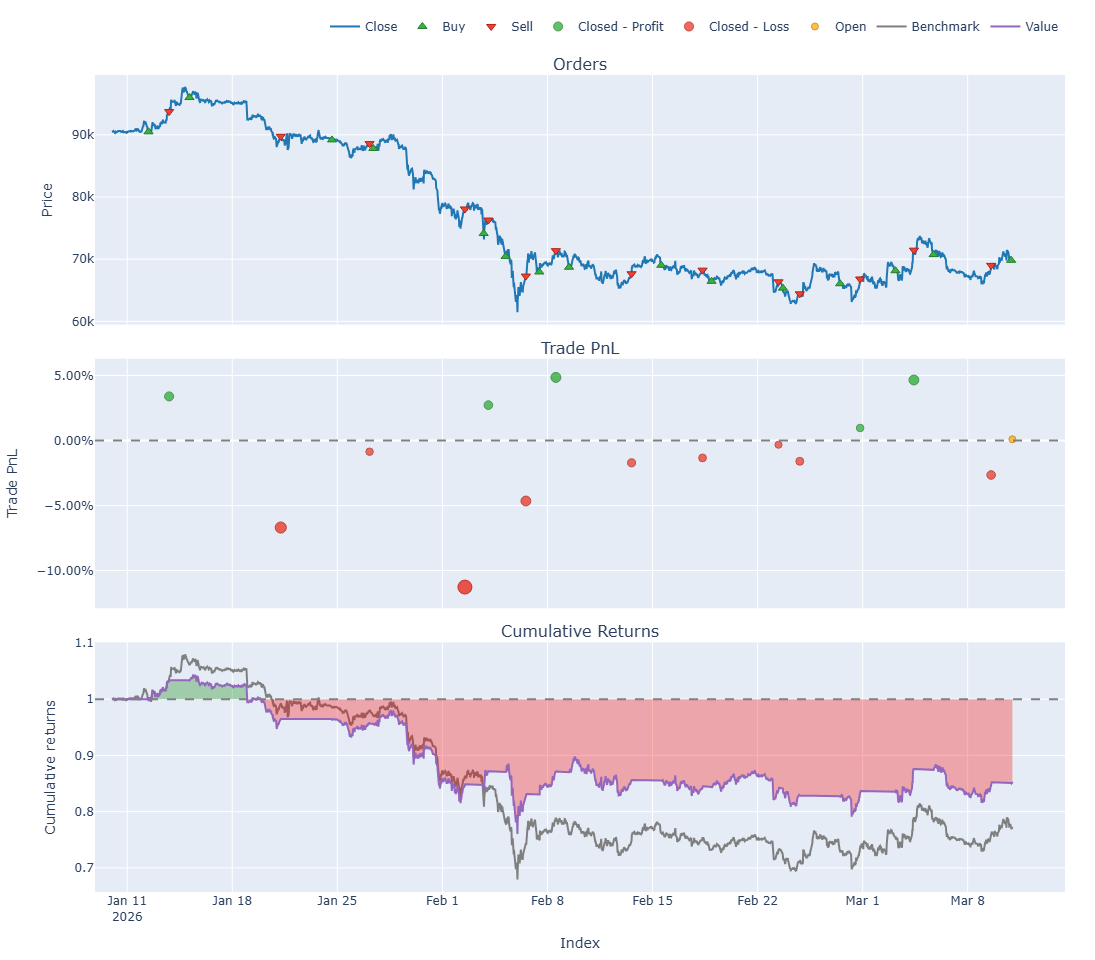

In [12]:
import vectorbt as vbt

close = vbt.YFData.download("BTC-USD", interval="30m").get("Close") # 5m, 15m, 30m, 1h
rsi = vbt.RSI.run(close, window=14)

entries = rsi.rsi < 20
exits = rsi.rsi > 80

pf = vbt.Portfolio.from_signals(
    close,
    entries,
    exits,
    fees=0.001,
    slippage=0.0005,
    freq="30min"
)

print(pf.stats())
pf.plot().show()